# Kezdés, kapcsolók

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

inv = np.linalg.inv

start_date = '2010-03-03'
end_date = '2018-10-31'
stop_date = '2018-10-17'

b_days = 250
Delta_t_mean = 60 # days
Delta_t_var  = 90 # days
t_start = 90 # optimalizálás kezdete

# Kockázat
sigma_0 = 0.05
sigma2 = sigma_0**2 / b_days

# Bayes
update = True # True -> frissítés, False -> korrekció

# Adatok betöltése

In [2]:
import requests
import io

url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_Cantini/securities_factors.csv'
response = requests.get(url)
data = pd.read_csv(io.StringIO(response.text))

url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_Cantini/top5_expectations.csv'
response = requests.get(url)
top5 = pd.read_csv(io.StringIO(response.text))

url = 'https://raw.githubusercontent.com/siklerjulianna/TDK-MBL/main/Data_Cantini/release_Selic.csv'
response = requests.get(url)
release_Selic = pd.read_csv(io.StringIO(response.text))

top5['BIR_exp'] = top5['BIRm_exp']
top5['BIR_var'] = top5['BIRm_var']

# Oszlopok sorrendje
data = data[['Date', 'CDI', 'BRLUS', 'IBOV', 'iDkA I3', 'iDkA P3', 'BIR', 'Selic']]
top5 = top5[['Data', 'BRL_exp', 'BIR_exp', 'Sel_exp', 'BRL_var', 'BIR_var', 'Sel_var']]

# Dátum szerinti indexelés
data.set_index('Date', inplace=True)
top5.set_index('Data', inplace=True)

data = data.loc[start_date : end_date]
top5 = top5.loc[start_date : end_date]

# BIR hiányzó adatok kitöltése az utolsó elérhető értékkel
data['BIR'] = data['BIR'].ffill()

# Kivesszük azokat a sorokat, amikor a tőzsde nem volt nyitva: amikor CDI-nek nem volt értéke
data.dropna(subset=['CDI'], inplace=True)

# Tizedes tört alak
data['CDI'] /= 100

display(data)
display(top5)

,CDI,BRLUS,IBOV,iDkA I3,iDkA P3,BIR,Selic
Date,,,,,,,
2010-03-03,0.000328,1.7846,67641.0,1872.855278,1874.937760,NaN,8.75
2010-03-04,0.000328,1.7888,67814.0,1873.271967,1876.696596,NaN,8.75
2010-03-05,0.000328,1.7824,68846.0,1872.256735,1879.319331,NaN,8.75
2010-03-08,0.000329,1.7826,68575.0,1868.369947,1882.094870,NaN,8.75
2010-03-09,0.000329,1.7899,69576.0,1870.624699,1883.875376,NaN,8.75
...,...,...,...,...,...,...,...
2018-10-25,0.000246,3.7014,84083.0,5506.424190,5422.827352,0.45,6.50
2018-10-26,0.000246,3.6753,85719.0,5529.569430,5453.486165,0.45,6.50
2018-10-29,0.000246,3.6368,83796.0,5525.465277,5459.342207,0.45,6.50


,BRL_exp,BIR_exp,Sel_exp,BRL_var,BIR_var,Sel_var
Data,,,,,,
2010-03-03,1.82,0.30,8.75,0.0001,0.0016,0.0289
2010-03-04,1.82,0.30,8.75,0.0001,0.0016,0.0289
2010-03-05,1.82,0.30,8.75,0.0001,0.0016,0.0289
2010-03-08,1.81,0.30,8.75,0.0001,0.0016,0.0289
2010-03-09,1.81,0.35,8.75,0.0001,0.0016,0.0289
...,...,...,...,...,...,...
2018-10-25,3.71,0.58,6.50,0.0004,0.0009,0.0000
2018-10-26,3.70,0.57,6.50,0.0009,0.0009,0.0000
2018-10-29,3.70,0.57,6.50,0.0009,0.0009,0.0000


# Ábrák: kumulatív hozam, értékek

In [3]:
names_secu = ['CDI', 'BRLUS', 'IBOV', 'iDkA I3', 'iDkA P3']
names_all  = ['CDI', 'BRLUS', 'IBOV', 'iDkA I3', 'iDkA P3', 'BIR', 'Selic']
names_top5 = ['BRL_exp', 'BIR_exp', 'Sel_exp']
names_top5_var = ['BRL_var', 'BIR_var', 'Sel_var']

/tmp/ipykernel_2890/960835160.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)


--- Figure 3: Securities cumulative returns ---


<Figure size 640x480 with 0 Axes>

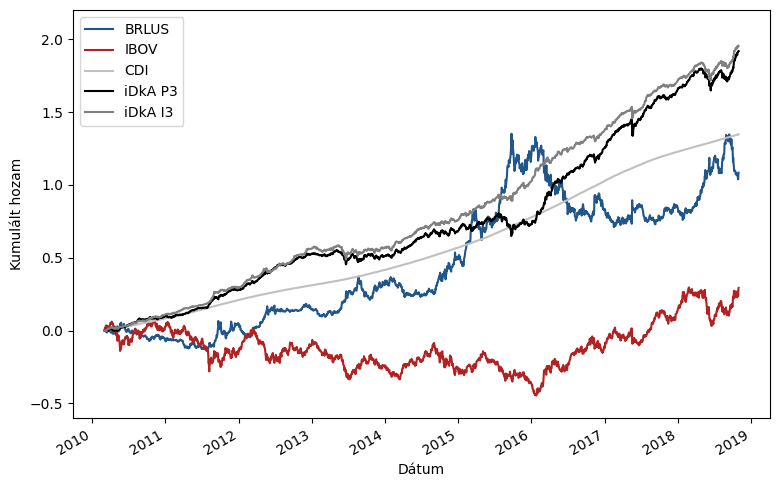

In [4]:
# Hozamok számítása
returns = data.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)

# CDI-t nem kell "hozamosítani"
returns['CDI'] = data['CDI']

# Dátum index beállítása
returns.index = pd.to_datetime(returns.index)

data.index = pd.to_datetime(data.index)
top5.index = pd.to_datetime(top5.index)

# Kumulatív hozamok
cumulative_growth = (1 + returns).cumprod() - 1

print("--- Figure 3: Securities cumulative returns ---")
plt.figure()
cumulative_growth[['BRLUS','IBOV','CDI','iDkA P3','iDkA I3']].plot(
    figsize=(9,6),
    color = ['#205689', 'firebrick', 'silver', 'black', 'grey'])
plt.ylim(-0.6, 2.2)
plt.xlabel('Dátum')
plt.ylabel('Kumulált hozam')
plt.savefig('Cantini_Kumulalt_tickers.pdf', bbox_inches='tight')
plt.legend()
plt.savefig("Fig3.pdf")
plt.show()
plt.close()

# BRL_exp újraszámolása

In [5]:
# Számoljuk ki az egyenletes napi hozamot, amely az aktuális árfolyamot a hónap végére várt értékre juttatja.
# Meghatározzuk a hónap végi dátumokat
hovegi_indexek = returns.groupby([returns.index.year, returns.index.month]).apply(lambda x: x.index.max())

for t in range(len(returns) - 2, -1, -1):
    t_date = pd.to_datetime(returns.index[t])
    t_tomorrow = pd.to_datetime(returns.index[t+1])
    jovo_hovegi_datumok = hovegi_indexek[hovegi_indexek > t_date]

    if not jovo_hovegi_datumok.empty:
        kov_hovege_idx = jovo_hovegi_datumok.iloc[0]
        kov_hovege_iloc = returns.index.get_loc(kov_hovege_idx)

        d = kov_hovege_iloc - t + 1

        # Kiszámoljuk az "egyenletes napi hozamot" a logika szerint
        current = data.loc[t_date, 'BRLUS']
        expect = top5.loc[t_date, 'BRL_exp']

        top5.loc[t_tomorrow, 'BRL_exp'] = ((expect / current)**(1/d) - 1)
        top5.loc[t_tomorrow, 'BRL_value'] = current * (expect / current)**(1/d)

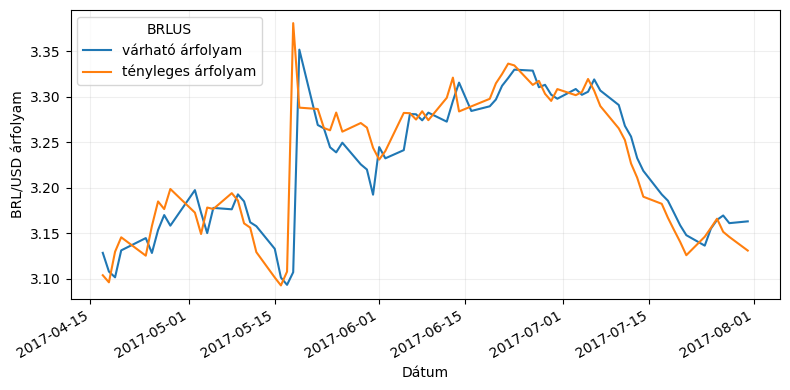

In [6]:
top5_zoom = top5['2017-04-15':'2017-07-31']
data_zoom = data['2017-04-15':'2017-07-31']

plt.figure()
top5_zoom['BRL_value'].plot(figsize = (8,4))
data_zoom['BRLUS'].plot(figsize = (8,4))
plt.legend(title = 'BRLUS', labels = ['várható árfolyam','tényleges árfolyam'])
plt.xlabel("Dátum")
plt.ylabel("BRL/USD árfolyam")
plt.tight_layout()
plt.grid(True, alpha=0.2)
plt.savefig("Arfolyam.pdf", bbox_inches='tight')
plt.show()
plt.close()

# Sel_exp újraszámolása

In [7]:
# BRL_exp-hez hasonló logika mentén simított alapkamatot számolunk
release_dates = pd.to_datetime(release_Selic.iloc[:, 0]).reset_index(drop=True)

for t in range(len(returns) - 2, -1, -1):
    t_date = pd.to_datetime(returns.index[t])
    t_tomorrow = pd.to_datetime(returns.index[t+1])

    jovo_release_datumok = release_dates[release_dates >= t_date]

    if not jovo_release_datumok.empty:
        kov_release = min(jovo_release_datumok)
        kov_release_iloc = returns.index.get_loc(kov_release)

        d = kov_release_iloc - t + 1

        current = data.loc[t_date, 'Selic']
        expect = top5.loc[t_date, 'Sel_exp']

        # Lineárisan interpolál a mai nap és a release_date között
        top5.loc[t_tomorrow, 'Sel_exp'] = current + (expect - current) /d

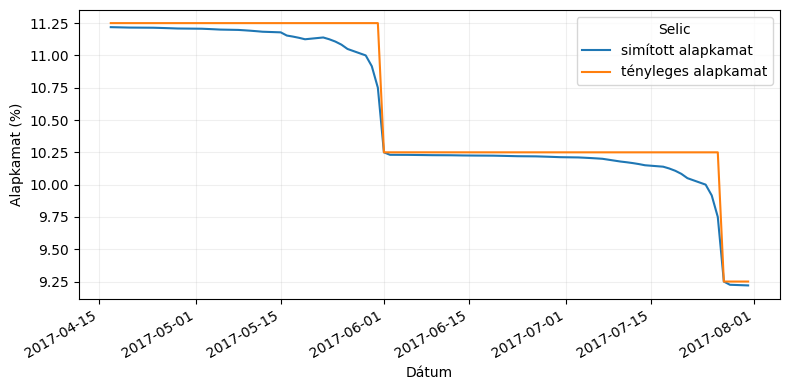

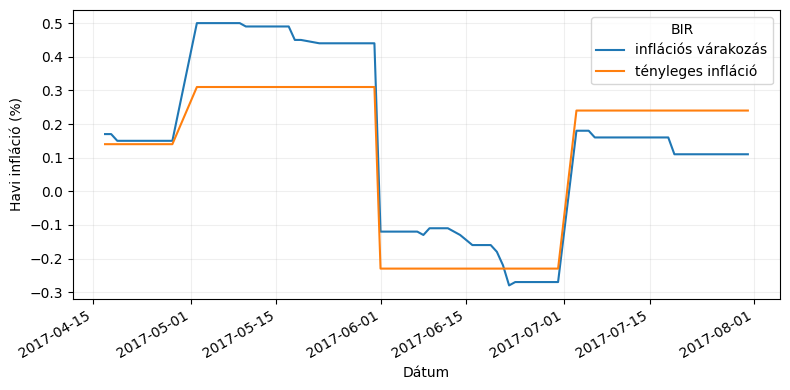

In [8]:
top5_zoom = top5['2017-04-15':'2017-07-31']
data_zoom = data['2017-04-15':'2017-07-31']

plt.figure()
top5_zoom['Sel_exp'].plot(figsize = (8,4))
data_zoom['Selic'].plot(figsize = (8,4))
plt.legend(title = 'Selic', labels = ['simított alapkamat','tényleges alapkamat'])
plt.xlabel("Dátum")
plt.ylabel("Alapkamat (%)")
plt.tight_layout()
plt.grid(True, alpha=0.2)
plt.savefig("Alapkamat.pdf", bbox_inches='tight')
plt.show()
plt.close()

plt.figure()
top5_zoom['BIR_exp'].plot(figsize = (8,4))
data_zoom['BIR'].plot(figsize = (8,4))
plt.legend(title = 'BIR', labels = ['inflációs várakozás','tényleges infláció'])
plt.xlabel("Dátum")
plt.ylabel("Havi infláció (%)")
plt.tight_layout()
plt.grid(True, alpha=0.2)
plt.savefig("Inflacio.pdf", bbox_inches='tight')
plt.show()
plt.close()

Értékpapírok korrelációs mátrixa

In [9]:
returns_zoom = returns['2010-03-03':'2018-10-17']
returns = returns['2010-03-03':'2018-10-17']

print("--- Table 2: Securities correlation (full sample period) ---")
display(returns_zoom[names_secu].corr())
returns_zoom[names_secu].corr().to_latex("Table2.tex", float_format="%.3f")

returns['BIR'] = data['BIR']
returns['Selic'] = data['Selic']

--- Table 2: Securities correlation (full sample period) ---


,CDI,BRLUS,IBOV,iDkA I3,iDkA P3
CDI,1.000000,-0.010177,0.007461,0.042203,0.036953
BRLUS,-0.010177,1.000000,-0.345549,-0.231788,-0.334385
IBOV,0.007461,-0.345549,1.000000,0.252460,0.312174
iDkA I3,0.042203,-0.231788,0.252460,1.000000,0.830522
iDkA P3,0.036953,-0.334385,0.312174,0.830522,1.000000


# Ciklus

In [10]:
s = len(names_secu)
k = len(names_top5)
n = len(names_all)

print(f"s = {s}, k = {k}, n = {n}")
print(f"starting from {returns.index[t_start]}")

# számolás
def calculate(isMBL, useBRL, isPV):

  all_dates = []
  all_weights = []

  for t in range(t_start,len(returns_zoom)):
    t_date = returns.index[t]

    if isMBL == 1:
      ####################################
      # Makrofactor-Black-Litterman-modell használatával

      # Vetítő mátrix
      P = np.zeros((k, n))

      P[0, returns.columns.get_loc('BRLUS')]     = useBRL
      P[1, returns.columns.get_loc('BIR')]       = 1
      P[2, returns.columns.get_loc('Selic')]     = 1

      # Perfect view (tökéletes előrelátás) vagy sem?
      if isPV == 1:
        q = returns.loc[t_date, ['BRLUS', 'BIR', 'Selic']].values
      else:
        q = top5.loc[t_date, ['BRL_exp', 'BIR_exp', 'Sel_exp']].values

      Pi    = returns[names_all].iloc[t-Delta_t_mean:t].mean().values
      Sigma = returns[names_all].iloc[t-Delta_t_var:t].cov().values

      variances = top5.loc[t_date, ['BRL_var', 'BIR_var', 'Sel_var']].values
      variances[variances == 0] = 1e-4
      Omega = np.diag(variances)

      # Ha szinguláris
      if np.isclose(np.linalg.det(Sigma), 0): Sigma += np.eye(len(Sigma))*1e-6
      if np.isclose(np.linalg.det(Omega), 0): Omega += np.eye(len(Omega))*1e-6

      if update:
        # Bayes-i frissítés
        V = inv (inv(Sigma)      + (P.T @ inv(Omega) @ P))
        m = V @ (inv(Sigma) @ Pi + (P.T @ inv(Omega) @ q))
      else:
        # Bayes-i korrekció
        V = Sigma + inv(inv(Sigma) + P.T @ inv(Omega) @ P)
        m = Pi + Sigma @ P.T @ inv((P @ Sigma @ P.T) + Omega) @ (q - P @ Pi)

      # Értékpapírok megtartása
      m_s = m[:s]
      V_s = V[:s, :s]
    else:
      ####################################
      # Markowitz-féle modell szerint (MVO)
      m_s = returns[names_secu].iloc[t-Delta_t_mean:t].mean().values
      V_s = returns[names_secu].iloc[t-Delta_t_var :t].cov().values

    w = cp.Variable(s)
    risk = cp.quad_form(w, V_s) / 2

    prob = cp.Problem(cp.Maximize(m_s.T @ w), [risk <= sigma2, cp.sum(w) == 1, w >= 0])
    prob.solve()

    wv = w.value
    wv[wv < 0] = 0

    all_weights.append(wv)
    all_dates.append(t_date)

  # Ciklus vége
  weights = pd.DataFrame(all_weights, index=all_dates, columns=names_secu)
  weights.index = pd.to_datetime(weights.index)

  return weights

s = 5, k = 3, n = 7
starting from 2010-07-12 00:00:00


# Összes portfólió kiszámolása

In [11]:
# isMBL (int), useBRL (int), isPV (int)

print("calculating MVO")
mvo_weights = calculate(0,1,0)

print("calculating MBL BCB")
mb3_weights = calculate(1,1,0)

print("calculating MBL PV")
mbp_weights = calculate(1,1,1)

print("calculating MBL PV -BRLUS")
mb__weights = calculate(1,0,1)

print("calculating MBL MCB -BRLUS")
mb2_weights = calculate(1,0,0)

calculating MVO
calculating MBL BCB
calculating MBL PV
calculating MBL PV -BRLUS
calculating MBL MCB -BRLUS


# Eredmények

In [12]:
# MVO
mvo_returns = returns[names_secu].loc[mvo_weights.index]
mvo_daily_returns = (mvo_weights * mvo_returns).sum(axis=1)

# MBL BCB
mb3_returns = returns[names_secu].loc[mb3_weights.index]
mb3_daily_returns = (mb3_weights * mb3_returns).sum(axis=1)

# MBL PV
mbp_returns = returns[names_secu].loc[mbp_weights.index]
mbp_daily_returns = (mbp_weights * mbp_returns).sum(axis=1)

# MBL PV -BRLUS
mb__returns = returns[names_secu].loc[mb__weights.index]
mb__daily_returns = (mb__weights * mb__returns).sum(axis=1)

# MBL BCB -BRLUS
mb2_returns = returns[names_secu].loc[mb2_weights.index]
mb2_daily_returns = (mb2_weights * mb2_returns).sum(axis=1)

# Benchmark hozam
benchmarks = mvo_returns[['CDI']]

# Összesítsük egy táblázatba az adatokat
performance_df = pd.DataFrame({
    'MVO': mvo_daily_returns,
    'MBL BCB': mb3_daily_returns,
    'MBL PV': mbp_daily_returns,
    'MBL PV -BRLUS': mb__daily_returns,
    'MBL BCB -BRLUS': mb2_daily_returns,
    'CDI': benchmarks['CDI']
    })

metrics = {}
for col in performance_df.columns:
    # Annualized Return (Geometriai)
    total_ret = (1 + performance_df[col]).prod()
    n_days = len(performance_df)
    ann_ret = (total_ret ** (b_days / n_days)) - 1

    # Annualized Volatility
    ann_vol = performance_df[col].std() * np.sqrt(b_days)

    # Sharpe Ratio (Rf = CDI átlagos évesített hozama)
    cdi_ann = ((1 + performance_df['CDI']).prod() ** (b_days / n_days)) - 1
    sharpe = (ann_ret - cdi_ann) / ann_vol if col != 'CDI' else 0

    # Maximum Drawdown
    cum_ret = (1 + performance_df[col]).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    max_dd = drawdown.min()

    metrics[col] = [ann_ret * 100, ann_vol * 100, - max_dd * 100, sharpe]

# Táblázat megjelenítése
table_3 = pd.DataFrame(metrics,
                       index=['Éves hozam', 'Éves $\sigma$',
                              'Max. visszaesés', 'Sharpe-ráta']).T
print("--- Table 3: Performance analysis ---")
formats = {col: "{:.2f}\%" for col in table_3.columns[:-1]}
formats[table_3.columns[-1]] = "{:.2f}"
table_3.style.format(formats).to_latex("Table3.tex",
                                       column_format="lcccc", hrules=True)

display(table_3)

--- Table 3: Performance analysis ---


<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\%'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2890/2128099996.py:58: SyntaxWarning: invalid escape sequence '\s'
  index=['Éves hozam', 'Éves $\sigma$',
/tmp/ipykernel_2890/2128099996.py:61: SyntaxWarning: invalid escape sequence '\%'
  formats = {col: "{:.2f}\%" for col in table_3.columns[:-1]}


,Éves hozam,Éves $\sigma$,Max. visszaesés,Sharpe-ráta
MVO,14.872990,6.996719,6.232566,0.646700
MBL BCB,17.742156,7.284721,7.831325,1.014994
MBL PV,40.891984,7.195372,3.650228,4.244919
MBL PV -BRLUS,16.925270,6.962618,7.070522,0.944625
MBL BCB -BRLUS,17.137708,7.187575,8.248555,0.944616
CDI,10.348210,0.144311,-0.000000,0.000000


# Ábrák

--- Figure 4: Cumulative returns ---


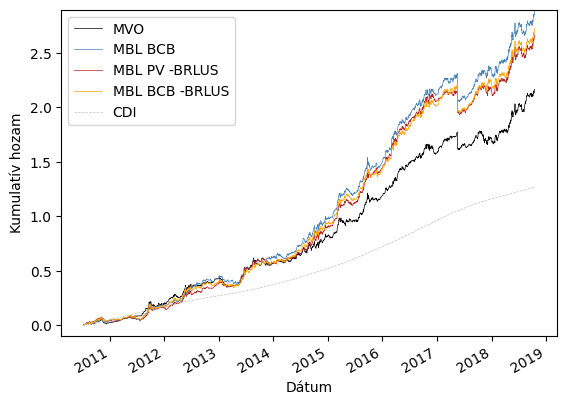

--- Figure 5: Allocations and cumulative return for MVO ---


<Figure size 640x480 with 0 Axes>

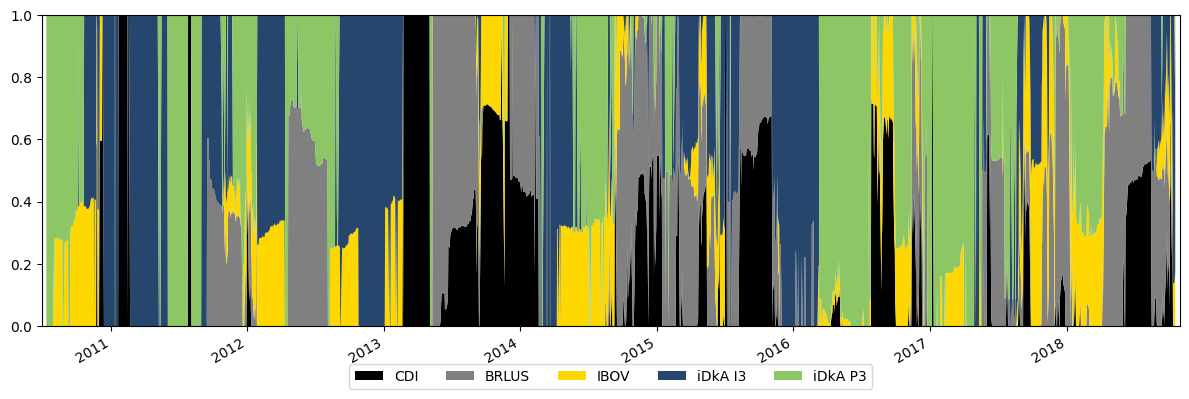

--- Figure 6: Allocations and cumulative return for MBL BCB ---


<Figure size 640x480 with 0 Axes>

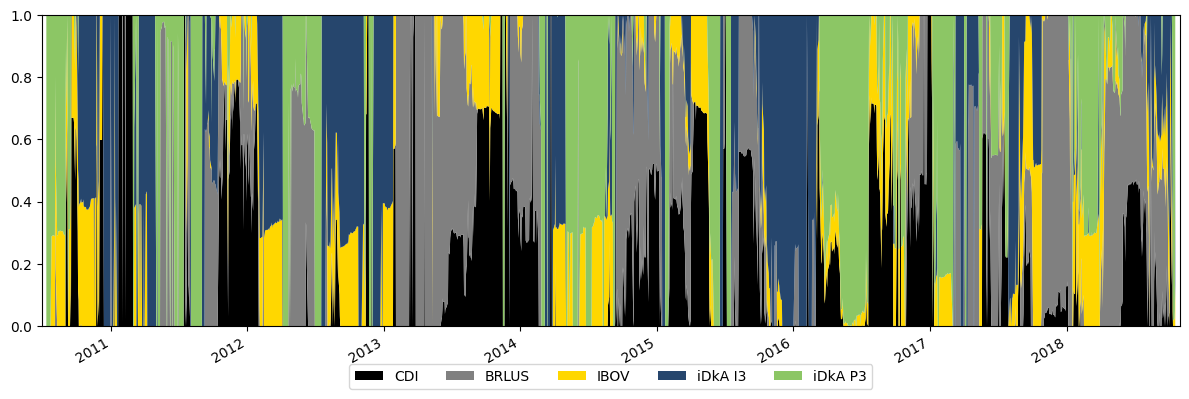

In [13]:
cumulative_growth = (1 + performance_df).cumprod() - 1

print("--- Figure 4: Cumulative returns ---")
plt.figure()
cumulative_growth['MVO'].plot(color = 'black', linestyle = '-', lw=0.5)
cumulative_growth['MBL BCB'].plot(color = 'steelblue', linestyle = '-', lw=0.5)
cumulative_growth['MBL PV -BRLUS'].plot(color = 'firebrick', linestyle = '-', lw=0.5)
cumulative_growth['MBL BCB -BRLUS'].plot(color = 'orange', linestyle = '-', lw=0.5)
cumulative_growth['CDI'].plot(color = 'silver', linestyle = '--', lw=0.5)
plt.xlabel("Dátum")
plt.ylabel("Kumulatív hozam")
plt.ylim(-0.1,2.9)
plt.legend(loc='upper left')
plt.savefig("Fig4.pdf")
plt.show()
plt.close()

print("--- Figure 5: Allocations and cumulative return for MVO ---")
plt.figure()
mvo_weights.plot.area(figsize=(12,4), linewidth=0,
                      color = ['black', 'grey', 'gold', '#26466D', '#8CC665'])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.tight_layout()
plt.xlim('2010-07-01','2018-10-31')
plt.ylim(0,1)
plt.savefig("Fig5.pdf")
plt.show()
plt.close()

print("--- Figure 6: Allocations and cumulative return for MBL BCB ---")
plt.figure()
mb3_weights.plot.area(figsize=(12,4), linewidth=0,
                      color = ['black', 'grey', 'gold', '#26466D', '#8CC665'])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5)
plt.tight_layout()
plt.xlim('2010-07-01','2018-10-31')
plt.ylim(0,1)
plt.savefig("Fig6.pdf")
plt.show()
plt.close()